<p align="center">
<img alt="Institution Logo" src="nhsm.png" width="120"/>
</p>

**Institution:** National Higher School of Mathematics  \
**Course:** Computer Vision \
**Instructor:** Pr. M. Hachama  \
**Date:** 11 / 02 / 2026  

---

**Full Name:** Zeroual Oussama \
**Student ID:** 202239345404 \
**Group / Section:** MS S8 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Panorama Image Stitching CODE

The following code implements a **panorama image stitching system** that combines multiple overlapping images into a single wide panoramic image. Here's a breakdown of what each part does:

## Main Functionality

The code takes **three overlapping images** (typically left, center, and right views of a scene) and stitches them together to create a seamless panorama.

## Key Components:

### 1. **Feature Detection and Matching**
- Uses **SIFT (Scale-Invariant Feature Transform)** to detect distinctive keypoints in each image
- Finds matching features between image pairs using brute-force matching
- The matches represent the same physical points in different images

### 2. **RANSAC for Robust Homography Estimation**
- Implements the **RANSAC algorithm** to find the best homography matrix while handling outliers
- Randomly selects 4 point correspondences, computes a homography, and finds inliers
- Repeats this process (max_iter=500) to find the model with most inliers
- The final homography is computed using only the inlier matches

### 3. **Image Warping and Blending**
- Warps the left and right images to align with the center image using the computed homographies
- Creates binary masks to handle overlapping regions
- Blends images together by multiplying with masks and adding

## Workflow:

1. **Input**: Three images (center, left, right)
2. **Feature matching**: Find SIFT matches between left-center and right-center pairs
3. **RANSAC**: Filter out bad matches and compute accurate homographies
4. **Warping**: Transform left/right images to align with center
5. **Blending**: Combine images using mask-based blending
6. **Output**: A single panoramic image

## The stitching process:
- Left image → warped to align with center
- Right image → warped to align with the blended result
- Padded center image serves as the base
- Masking prevents ghosting and artifacts in overlapping regions

This is a classic computer vision pipeline for creating panoramas from multiple overlapping photographs, similar to what apps like Google Photos or smartphone camera panorama modes do automatically.

In [3]:
def load_image(filename):
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img
img = load_image("imag1.jpg")

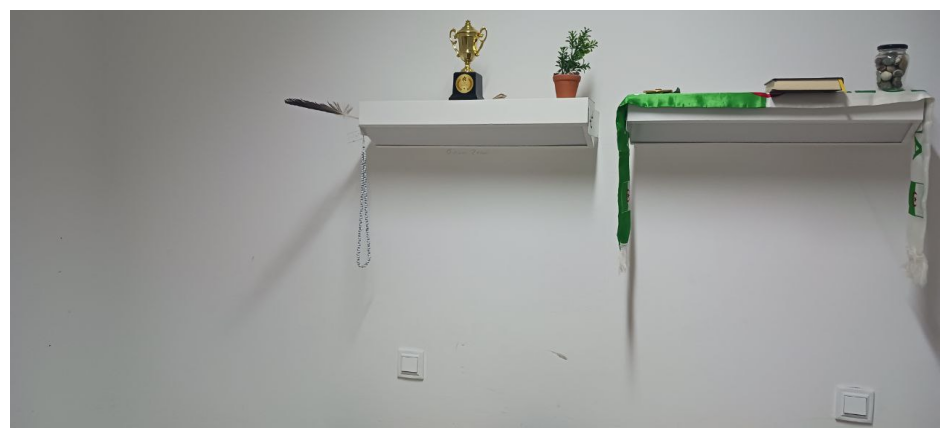

In [4]:
def show_image(img):
    fig = plt.figure()
    fig.set_size_inches(12, 8)
    if len(img.shape) == 3:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

show_image(img)

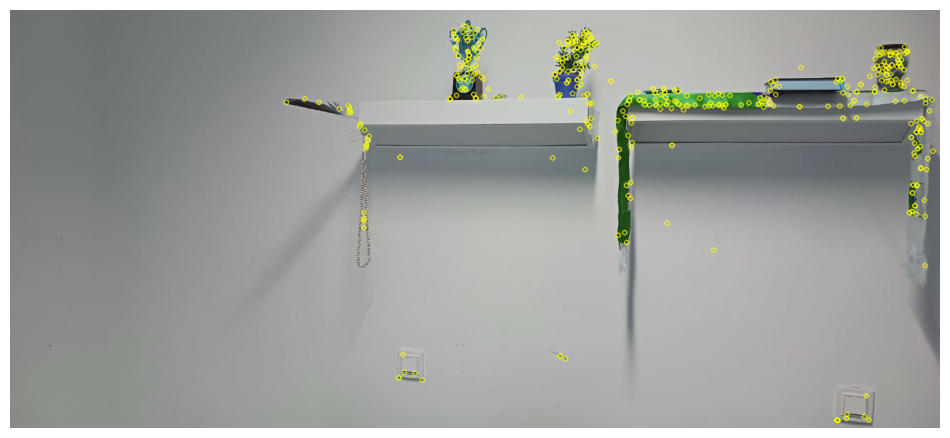

In [5]:
def testSIFT(img):
    """Test SIFT keypoint detection"""
    sift = cv2.SIFT_create(nfeatures=500)
    kp = sift.detect(img, None)
    img1_copy = img.copy()
    img1_copy = cv2.drawKeypoints(img1_copy, kp, None, color=(0, 255, 255))
    fig = plt.figure()
    fig.set_size_inches(12, 8)
    plt.imshow(cv2.cvtColor(img1_copy, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    
testSIFT(img)

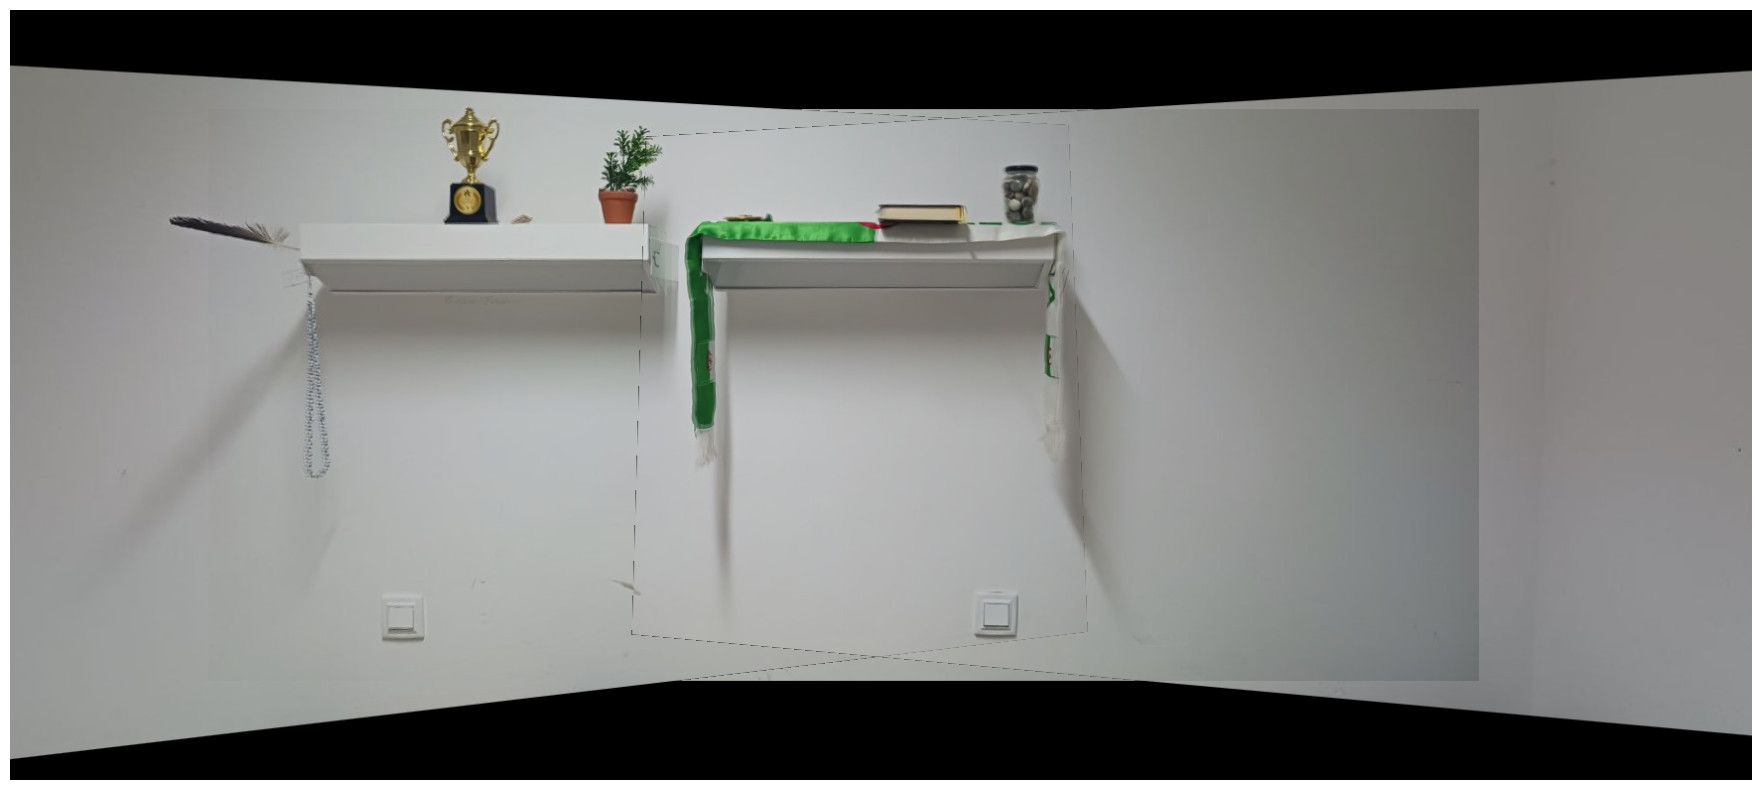

In [ ]:
def compute_homography(src_pts, dst_pts):
    """Compute homography from source to destination points"""
    N = src_pts.shape[0]
    H = []
    src_array = np.asarray(src_pts)
    dst_array = np.asarray(dst_pts)
    
    for n in range(N):
        src = src_array[n]
        H.append(-src[0])
        H.append(-src[1])
        H.append(-1)
        H.append(0)
        H.append(0)
        H.append(0)
    
    H = np.asarray(H)
    H1 = H.reshape(2 * N, 3)
    
    H2 = np.zeros([2 * N, 3], dtype=int)
    for i in range(0, 2 * N, 2):
        H2[i:i + 2, 0:i + 3] = np.flip(H1[i:i + 2, 0:i + 3], axis=0)
    
    H2 = np.asarray(H2)
    H3 = np.concatenate((H1, H2), axis=1)
    
    H4 = []
    for n in range(N):
        src = src_array[n]
        dst = dst_array[n]
        
        H4.append(src[0] * dst[0])
        H4.append(src[1] * dst[0])
        H4.append(dst[0])
        H4.append(src[0] * dst[1])
        H4.append(src[1] * dst[1])
        H4.append(dst[1])
    
    H4 = np.asarray(H4)
    H4 = H4.reshape(2 * N, 3)
    
    H5 = np.concatenate((H3, H4), axis=1)
    H8 = np.matmul(np.transpose(H5), H5)
    
    w, v = np.linalg.eig(H8)
    minimum = w.min()
    
    for i in range(len(w)):
        if w[i] == minimum:
            a = v[:, i]
    
    a = np.asarray(a)
    a = a.reshape(3, 3)
    a = a / a[2, 2] 
    return a

def apply_homography(test, H):
    """Apply homography to test points"""
    N = test.shape[0]
    dst_output = []
    
    for row in test:
        input_pt = np.matrix([row[0, 0], row[0, 1], 1])
        input_pt = input_pt.transpose()
        mapped_pts = np.matmul(H, input_pt)
        dst_output.append(mapped_pts[0] / mapped_pts[2])
        dst_output.append(mapped_pts[1] / mapped_pts[2])
    
    dst_output = np.asarray(dst_output)
    dst_output = dst_output.reshape(N, 2)
    
    return dst_output

def genSIFTMatchPairs(img1, img2):
    """Generate SIFT matches between two images"""
    sift = cv2.SIFT_create(nfeatures=2000)  
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True) 
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Take more matches
    num_matches = min(500, len(matches))  # Increased from 250
    pts1 = np.zeros((num_matches, 2))
    pts2 = np.zeros((num_matches, 2))
    for i in range(num_matches):
        pts1[i, :] = kp1[matches[i].queryIdx].pt
        pts2[i, :] = kp2[matches[i].trainIdx].pt
    
    return pts1, pts2, matches[:num_matches], kp1, kp2


def RANSAC(Xs, Xd, max_iter = 1000, eps = 10):
    """RANSAC algorithm for homography estimation"""
    H = np.zeros([3, 3])
    
    inliers_ids = []
    inliers_counts = []
    
    n = Xs.shape[0]
    
    iter_count = 0
    while iter_count < max_iter:
        inliers_id = []
        pts_index = random.sample(range(0, n), 4)
        
        Xs_new = []
        Xd_new = []
        
        for pt in range(4):
            Xs_new.append(Xs[pts_index[pt]][:])
            Xd_new.append(Xd[pts_index[pt]][:])
        
        Xs_new = np.asarray(Xs_new)
        Xd_new = np.asarray(Xd_new)
        Xs_new = np.asmatrix(Xs_new)
        Xd_new = np.asmatrix(Xd_new)
        
        H = compute_homography(Xs_new, Xd_new)
        
        Xs_matrix = np.asmatrix(Xs)
        Xd_predicted = apply_homography(Xs_matrix, H)
        
        for i in range(n):
            # Use np.round instead of built-in round
            SSD = ((np.round(Xd_predicted[i][0]) - int(Xd[i, 0])) ** 2 + 
                   (np.round(Xd_predicted[i][1]) - int(Xd[i, 1])) ** 2)
            
            if SSD < eps:
                if i not in inliers_id:
                    inliers_id.append(i)
        
        inliers_ids.append(inliers_id)
        inliers_counts.append(len(inliers_id))
        
        iter_count += 1
    
    largest_count_index = inliers_counts.index(max(inliers_counts))
    best_inliers_id = inliers_ids[largest_count_index]
    
    Xs_inliers = []
    Xd_inliers = []
    for i in best_inliers_id:
        Xs_inliers.append(Xs[i][:])
        Xd_inliers.append(Xd[i][:])
    
    Xs_inliers = np.asarray(Xs_inliers)
    Xd_inliers = np.asarray(Xd_inliers)
    Xs_inliers = np.asmatrix(Xs_inliers)
    Xd_inliers = np.asmatrix(Xd_inliers)
    
    H = compute_homography(Xs_inliers, Xd_inliers)
    
    return best_inliers_id, H

def binary_mask(img):
    """Create binary mask from image"""
    gray = cv2.cvtColor(img.astype('uint8'), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    return mask


def warp_img(img, H, output_size):
    """Warp image using homography"""
    h, w = output_size
    warped = cv2.warpPerspective(img, H, (w, h))
    return warped

def blend_images(img1, img2):
    """Blend two images with weighted averaging in overlap region"""
    # Create masks
    mask1 = binary_mask(img1) / 255.0
    mask2 = binary_mask(img2) / 255.0
    overlap = mask1 * mask2
    h, w = overlap.shape
    weight1 = np.ones_like(mask1)
    weight2 = np.ones_like(mask2)
    # Simple linear blending in overlap
    for i in range(h):
        for j in range(w):
            if overlap[i, j] > 0:
                weight1[i, j] = j / w
                weight2[i, j] = 1 - weight1[i, j]
    weight1 = np.stack((weight1,) * 3, axis=-1)
    weight2 = np.stack((weight2,) * 3, axis=-1)
    mask1_3ch = np.stack((mask1,) * 3, axis=-1)
    mask2_3ch = np.stack((mask2,) * 3, axis=-1)
    result = (img1 * weight1 + img2 * weight2) / (weight1 + weight2 + 1e-8)
    result = np.where(mask1_3ch == 0, img2, result)
    result = np.where(mask2_3ch == 0, img1, result)
    
    return result.astype(np.uint8)
def stitch_img(imgs):
    """Stitch a list of images together with improved blending"""
    img_center = imgs[0]
    img_left = imgs[1]
    img_right = imgs[2]
    pad_size = 400
    img_center_padded = np.pad(img_center, pad_width=((pad_size, pad_size), (pad_size, pad_size), (0, 0)))
    pts1, pts2, matches1to2, kp1, kp2 = genSIFTMatchPairs(img_left, img_center_padded)
    inliers_idx, H = RANSAC(pts1, pts2, 1000, 25)  # Better parameters
    dst_img = warp_img(img_left, H, [img_center_padded.shape[0], img_center_padded.shape[1]])
    out_img = blend_images(img_center_padded, dst_img)
    pts1, pts2, matches1to2, kp1, kp2 = genSIFTMatchPairs(img_right, out_img)
    inliers_idx, H = RANSAC(pts1, pts2, 1000, 25)
    dst_img = warp_img(img_right, H, [out_img.shape[0], out_img.shape[1]])
    out_img_final = blend_images(out_img, dst_img)
    
    return out_img_final
def test_matches():
    """Test and visualize SIFT matches"""
    img1 = cv2.imread('Newman1.png')
    img2 = cv2.imread('Newman2.png')
    pts1, pts2, matches1to2, kp1, kp2 = genSIFTMatchPairs(img1, img2)
    matching_result = cv2.drawMatches(img1, kp1, img2, kp2, matches1to2, None, flags=2,matchColor=(255, 255, 0), singlePointColor=(0, 0, 255))
    fig = plt.figure()
    fig.set_size_inches(18, 10)
    plt.imshow(cv2.cvtColor(matching_result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

def test_ransac():
    """Test RANSAC implementation"""
    img1 = cv2.imread('image1.jpg')
    img2 = cv2.imread('image2.jpg')
    pts1, pts2, matches1to2, kp1, kp2 = genSIFTMatchPairs(img1, img2)
    inliers_idx, H = RANSAC(pts1, pts2, 500, 50)
    new_matches = []
    for i in range(len(inliers_idx)):
        new_matches.append(matches1to2[inliers_idx[i]])
    matching_result = cv2.drawMatches(img1, kp1, img2, kp2, new_matches, None, flags=2,matchColor=(255, 255, 0), singlePointColor=(0, 0, 255))
    fig = plt.figure()
    fig.set_size_inches(18, 10)
    plt.imshow(cv2.cvtColor(matching_result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

def create_panorama_from_files(img_files, output_crop=(300, 200, 300, 125)):
    imgs = []
    for f in img_files:
        img = cv2.imread(f)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgs.append(img)
    final_stitch = stitch_img(imgs)
    top, bottom, left, right = output_crop
    cropped = final_stitch[top:final_stitch.shape[0] - bottom, left:final_stitch.shape[1] - right].astype("uint8")
    fig = plt.figure()
    fig.set_size_inches(25, 10)
    plt.imshow(cropped)
    plt.axis('off')
    plt.show()
    
    return final_stitch, cropped


if __name__ == "__main__":
    left_img = cv2.imread("imag1.jpg")
    center_img = cv2.imread("imag2.jpg")
    right_img = cv2.imread("imag3.jpg")
    left_img = cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB)
    center_img = cv2.cvtColor(center_img, cv2.COLOR_BGR2RGB)
    right_img = cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB)
    final_stitch = stitch_img([center_img, left_img, right_img])
    fig = plt.figure()
    fig.set_size_inches(25, 10)
    plt.imshow(final_stitch[300:final_stitch.shape[0] - 300, 200:final_stitch.shape[1] - 125].astype("uint8"))
    plt.axis('off')
    plt.show()